**XYLOFY AI INTERNSHIP WEEK-2 PROJECT**
---

**Name: VANCHANAGIRI ALEKHYA**

**Mail Id: alekhya03v@gmail.com**


**Employee Attrition Prediction using Machine Learning**
---

**1. Project Overview**
---
People changing jobs is just a normal part of business, but when a company unexpectedly loses its best talent, it causes a lot of stress, slows down projects, and costs a huge amount of money to fix. In this project, machine learning techniques are used to predict whether an employee is likely to leave the company based on various factors such as job satisfaction, salary, work-life balance, years at the company, and performance ratings.


The workflow includes:

* Understanding and exploring the HR dataset

* Cleaning and preprocessing the data
* Converting categorical features into numerical form
* Handling class imbalance using Over Sampling (RandomOverSampler)
* Building prediction models using Logistic Regression, Random Forest, and Gradient Boosting Classifiers
* Evaluating model performance using standard classification metrics
* Visualizing important relationships within the dataset
* Drawing meaningful HR insights and business recommendations

The objective is not only to build an accurate prediction model but also to understand what actually drives employees to leave, delivering insights that an HR team can act on immediately.

**2. Importing the Required Libraries**
---

In [ ]:
# Libraries for data manipulation
import pandas as pd
import numpy as np
from collections import Counter

# Libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Set a clean plotting style
sns.set_style("whitegrid")

print("All required libraries have been imported successfully.")

All required libraries have been imported successfully.


**3. Loading the Dataset**
---

The first step is to load the dataset. Here, the IBM HR Analytics Employee Attrition dataset is read using the Pandas library and stored in a DataFrame.

After loading the data, the first few records are displayed to verify that the dataset has been imported correctly.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
hr_data = pd.read_csv("/content/drive/MyDrive/XylofyAI/Week-2/EmployeeAttrition_VanchanagiriAlekhya/HR_Attrition.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


Displaying First 10 Records
---

In [ ]:
display(hr_data.head(10))

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [ ]:
print(f"\nNumber of rows or records   : {hr_data.shape[0]}")
print(f"Number of columns or features : {hr_data.shape[1]}")


Number of rows or records   : 1470
Number of columns or features : 35


Exploring the Dataset
---
Before building any machine learning model, it is important to understand the structure of the dataset.

In this section, we examine:

* The target variable (Attrition)
* The balance of classes (who left vs who stayed)
* The number of numerical and categorical columns

Dataset Information
---


In [ ]:
print("Shape of the Dataset")
print("-----------")
print(hr_data.shape)

print("\nDataset Information")
print("-----------------------------" )
hr_data.info()

Shape of the Dataset
-----------
(1470, 35)

Dataset Information
-----------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-nu

Analyzing the Target Variable (Attrition)
---

In [ ]:
# Identifying the target column and calculating the attrition rate
attrition_counts = hr_data['Attrition'].value_counts()
attrition_rate = (attrition_counts['Yes'] / hr_data.shape[0]) * 100

print("Count of employees who left vs stayed:")
print(attrition_counts)
print(f"\nOverall Attrition Rate: {attrition_rate:.2f}%")

Count of employees who left vs stayed:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Overall Attrition Rate: 16.12%


**Observation:**

The dataset contains 1,470 observations and 35 features, including both numerical and categorical variables.

The target variable is Attrition, and it is highly imbalanced.

Only about 16% of employees left the company, while 84% stayed.

If we train a model without handling this imbalance, it might just predict "No" for everyone and still get an 84% accuracy, which is useless for HR.

We will address this soon using resampling techniques.

**4. Data Cleaning**
---

After examining the dataset, the necessary cleaning steps are performed. We will check for missing values and drop columns that add no value to our prediction.

Checking Missing Values
---

In [ ]:
missing_value_summary = hr_data.isnull().sum()
total_missing = missing_value_summary.sum()

print("Total Missing Values in Dataset")
print("-" * 40)
print(total_missing)

Total Missing Values in Dataset
----------------------------------------
0


Dropping Irrelevant Columns & Converting Target
---

In [ ]:
# Dropping columns that do not add predictive value
# EmployeeNumber is an ID, Over18 is 'Y' for everyone, StandardHours is 80 for everyone
columns_to_drop = ['EmployeeNumber', 'Over18', 'StandardHours', 'EmployeeCount']

cols_present = [col for col in columns_to_drop if col in hr_data.columns]
hr_data = hr_data.drop(columns=cols_present)

print("Updated Dataset Shape after dropping irrelevant columns")
print("-" * 40)
print(hr_data.shape)


Updated Dataset Shape after dropping irrelevant columns
----------------------------------------
(1470, 31)


In [ ]:
# Converting the target 'Attrition' column from Yes/No to 1/0
hr_data['Attrition'] = hr_data['Attrition'].map({'Yes': 1, 'No': 0})
print("\nConverted 'Attrition' from Yes/No to 1/0 successfully.")


Converted 'Attrition' from Yes/No to 1/0 successfully.


**5. Exploratory Data Analysis**
---
Data visualization helps in understanding the distribution of employee turnover, relationships between different variables, and the root causes of attrition.

In [ ]:
# Creating an 'eda' dataframe to map 'Attrition' back to 'Yes'/'No' for clear visualizations
eda = hr_data.copy()
eda['Attrition'] = eda['Attrition'].map({1: 'Yes', 0: 'No'})

Attrition by Department
---

In [ ]:
dept = pd.crosstab(
    eda["Department"],
    eda["Attrition"],
    normalize="index"
) * 100

dept = dept.sort_values("Yes", ascending=False)
display(dept)

Attrition,No,Yes
Department,,
Sales,79.372197,20.627803
Human Resources,80.952381,19.047619
Research & Development,86.160250,13.839750


Department Bar Plot
---

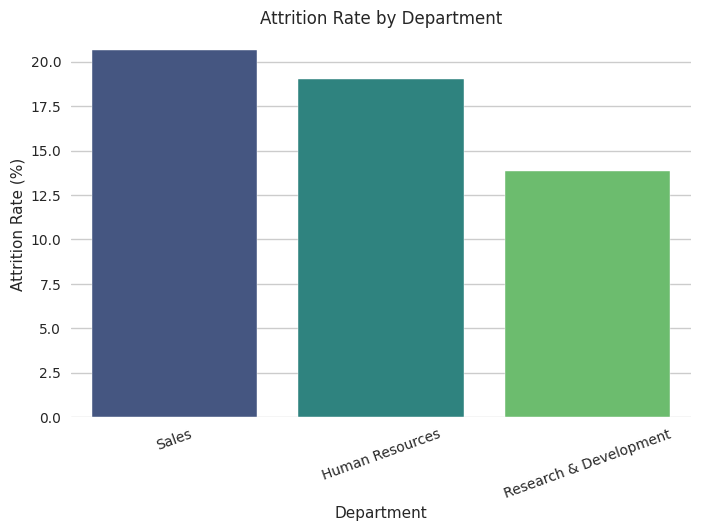

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=dept.index,
    y=dept["Yes"],
    palette="viridis"
)

plt.ylabel("Attrition Rate (%)")
plt.title("Attrition Rate by Department")
plt.xticks(rotation=20)
plt.show()

Attrition Rate by Job Role
---

In [ ]:
role = pd.crosstab(
    eda["JobRole"],
    eda["Attrition"],
    normalize="index"
) * 100

role = role.sort_values("Yes", ascending=False)
display(role)

Attrition,No,Yes
JobRole,,
Sales Representative,60.240964,39.759036
Laboratory Technician,76.061776,23.938224
Human Resources,76.923077,23.076923
Sales Executive,82.515337,17.484663
Research Scientist,83.904110,16.095890
Manufacturing Director,93.103448,6.896552
Healthcare Representative,93.129771,6.870229
Manager,95.098039,4.901961
Research Director,97.500000,2.500000


Job Role Bar Plot
---

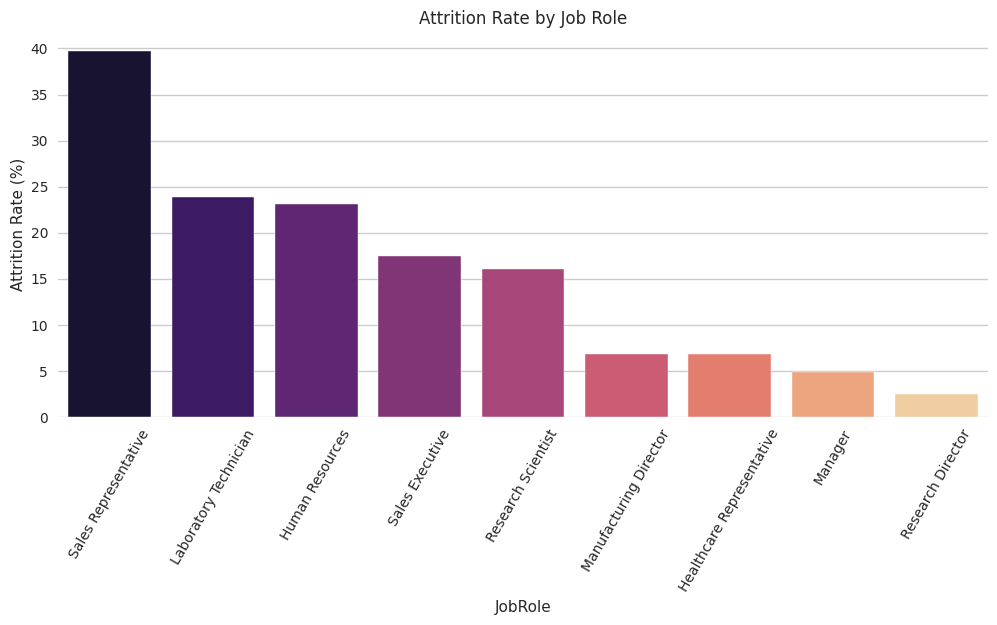

In [ ]:
plt.figure(figsize=(12,5))

sns.barplot(
    x=role.index,
    y=role["Yes"],
    palette="magma"
)

plt.xticks(rotation=60)
plt.ylabel("Attrition Rate (%)")
plt.title("Attrition Rate by Job Role")
plt.show()

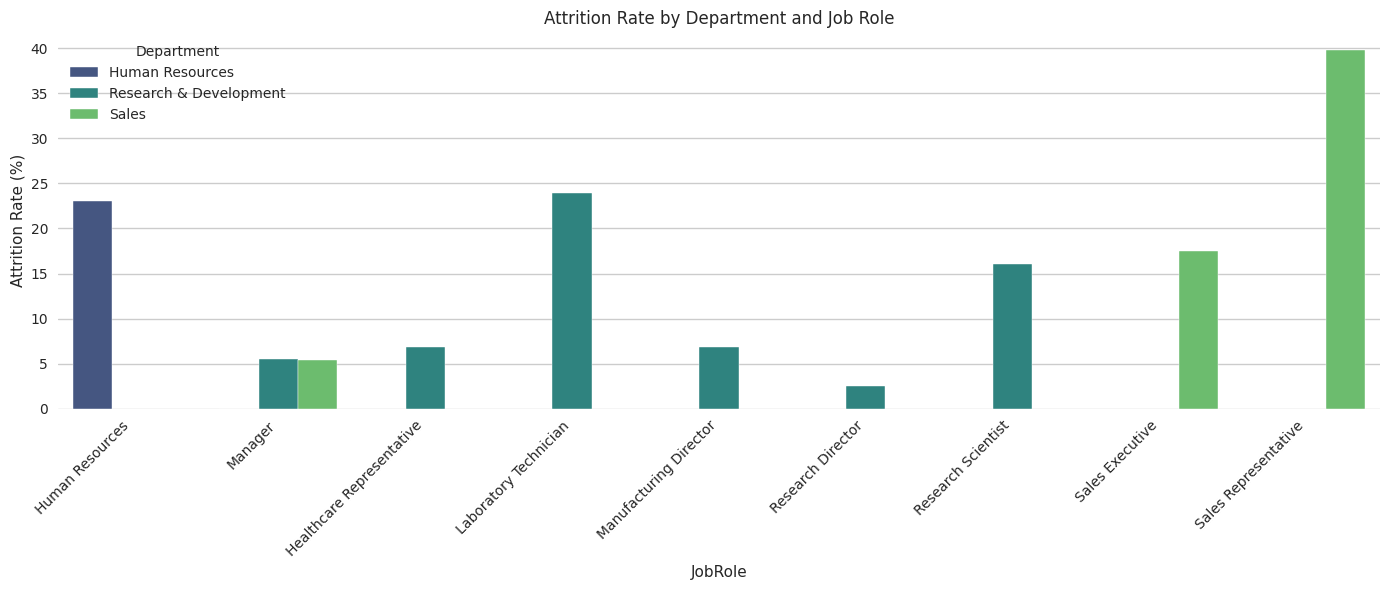

In [ ]:
plt.figure(figsize=(14, 6))

grouped = hr_data.groupby(['Department', 'JobRole'])['Attrition'].mean().reset_index()
grouped['Attrition'] *= 100

sns.barplot(data=grouped, x='JobRole', y='Attrition', hue='Department', palette='viridis')
plt.title('Attrition Rate by Department and Job Role')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Observation**

The Sales department has the highest attrition rate, with Sales Representatives leaving at an alarming rate of nearly 40%.

Work Life Balance vs Attrition Countplot
---

In [ ]:
wlb_attrition = hr_data.groupby('WorkLifeBalance')['Attrition'].mean() * 100
print("Attrition Rate by Work-Life Balance Rating (%):")
print(wlb_attrition)

Attrition Rate by Work-Life Balance Rating (%):
WorkLifeBalance
1    31.250000
2    16.860465
3    14.221725
4    17.647059
Name: Attrition, dtype: float64


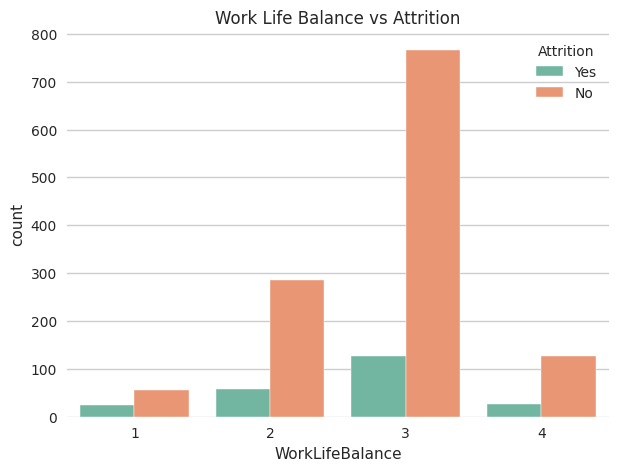

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="WorkLifeBalance",
    hue="Attrition",
    data=eda,
    palette="Set2"
)

plt.title("Work Life Balance vs Attrition")
plt.show()

**Observation**

Employees reporting a poor work-life balance (Rating 1) have the highest attrition rates.

Attrition vs Monthly Income
---

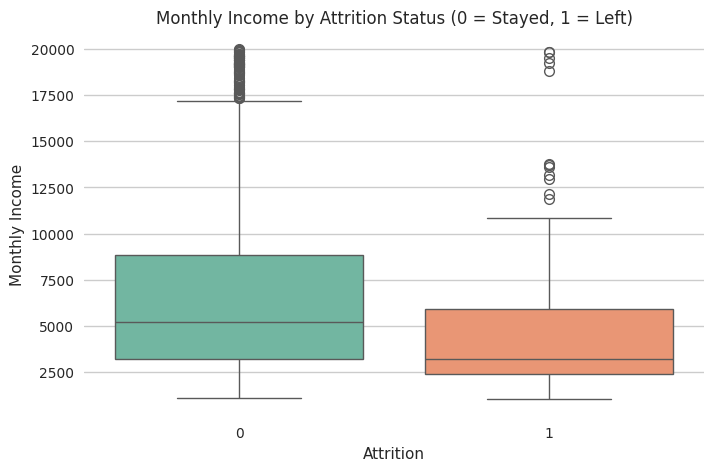

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=hr_data, palette='Set2')
plt.title('Monthly Income by Attrition Status (0 = Stayed, 1 = Left)')
plt.xlabel('Attrition')
plt.ylabel('Monthly Income')
plt.show()

**Observation**

There is a clear link between salary and attrition. The median monthly income of employees who left the company is noticeably lower than those who stayed.

Attrition vs Tenure
---

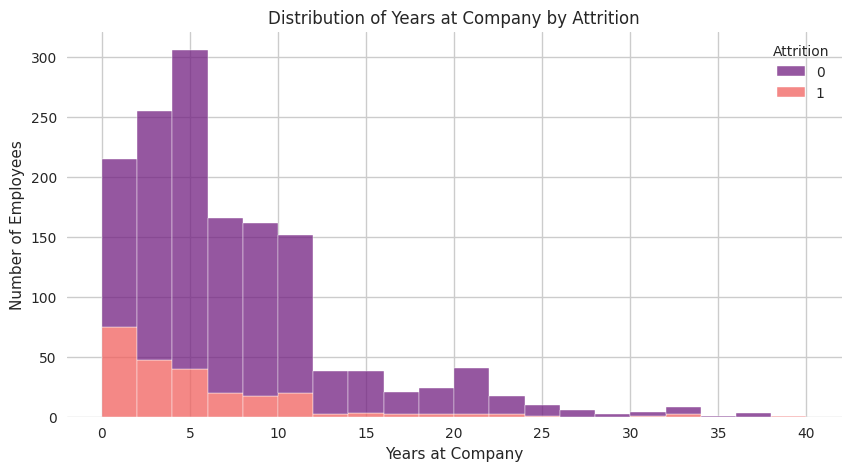

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(data=hr_data, x='YearsAtCompany', hue='Attrition', multiple='stack', bins=20, palette='magma')
plt.title('Distribution of Years at Company by Attrition')
plt.xlabel('Years at Company')
plt.ylabel('Number of Employees')
plt.show()

**Observation**

Looking at tenure, there is a massive spike in employees leaving during their first 2 to 5 years at the company.

**6. Data Preprocessing**
---

Machine learning algorithms require numerical input, whereas this dataset contains several categorical features represented as text (e.g., Department, JobRole, MaritalStatus).

To make these features suitable for model training, we apply One-Hot Encoding. We also scale the numerical features so that large values (like salary) do not overpower smaller values (like years at company).

One-Hot Encoding
---

In [ ]:
categorical_features = hr_data.select_dtypes(include="object").columns

print("Categorical Features to Encode")
print("-" * 40)
print(categorical_features.tolist())

# Applying One-Hot Encoding
hr_encoded = pd.get_dummies(
    hr_data,
    columns=categorical_features,
    drop_first=True
)

print("\nDataset Shape after encoding:", hr_encoded.shape)

Categorical Features to Encode
----------------------------------------
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Dataset Shape after encoding: (1470, 45)


Preparing the Dataset for Model Training
---

In [ ]:
# Separating input features (X) and target variable (y)
input_features = hr_encoded.drop(columns="Attrition")
target_variable = hr_encoded["Attrition"]

# Scaling numerical features
scaler = StandardScaler()
input_features_scaled = pd.DataFrame(scaler.fit_transform(input_features), columns=input_features.columns)

print("Input Feature Matrix Shape :", input_features_scaled.shape)
print("Target Variable Shape      :", target_variable.shape)

Input Feature Matrix Shape : (1470, 44)
Target Variable Shape      : (1470,)


Handling Class Imbalance (Resampling)
---
As observed earlier, the dataset is heavily imbalanced with far more employees staying (class 0) than leaving (class 1). To prevent our models from becoming biased, we apply Random Over Sampling.

This technique creates random duplicates of the minority class (those who left) until both classes have an equal number of records. (Note: We avoid Undersampling to prevent data loss).

**Random Over Sampling**

In [ ]:
print("Class Distribution Before Resampling:")
print("-" * 40)
print(Counter(target_variable))

# Applying RandomOverSampler
ros = RandomOverSampler(random_state=42)
features_oversampled, target_oversampled = ros.fit_resample(input_features_scaled, target_variable)

print("\nClass Distribution After Resampling:")
print("-" * 40)
print(Counter(target_oversampled))

Class Distribution Before Resampling:
----------------------------------------
Counter({0: 1233, 1: 237})

Class Distribution After Resampling:
----------------------------------------
Counter({1: 1233, 0: 1233})


**Train Test Split**

In [ ]:
# Splitting the oversampled dataset into training and testing sets
training_features, testing_features, training_target, testing_target = train_test_split(
    features_oversampled,
    target_oversampled,
    test_size=0.20,
    random_state=42
)

print("Training Feature Shape :", training_features.shape)
print("Testing Feature Shape  :", testing_features.shape)

Training Feature Shape : (1972, 44)
Testing Feature Shape  : (494, 44)


**7. Model Building & Evaluation**
---
We will train and compare three different classification models on our balanced dataset:

1. Logistic Regression (Serves as a strong, explainable baseline)
2. Random Forest Classifier (An ensemble model that captures complex patterns)
3. Gradient Boosting Classifier (A powerful boosting algorithm)

Training Models
---

In [ ]:
# Initialize models
log_reg = LogisticRegression(random_state=42)
rf_model = RandomForestClassifier(random_state=42)
gb_model = GradientBoostingClassifier(random_state=42)

# Train models
log_reg.fit(training_features, training_target)
rf_model.fit(training_features, training_target)
gb_model.fit(training_features, training_target)

print("All models trained successfully.")

All models trained successfully.


**Evaluating the Models**
---

In [ ]:
def evaluate_model(model, name, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

results = []
results.append(evaluate_model(log_reg, 'Logistic Regression', testing_features, testing_target))
results.append(evaluate_model(rf_model, 'Random Forest', testing_features, testing_target))
results.append(evaluate_model(gb_model, 'Gradient Boosting', testing_features, testing_target))

**8. Comparing the Performance of Models**
---

To understand which algorithm performs better on the HR dataset, the evaluation metrics of our models are summarized in a comparison table

In [ ]:
# Comparing classification models
performance_summary = pd.DataFrame(results).round(3)
display(performance_summary)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.771,0.770,0.766,0.768,0.857
1,Random Forest,0.962,0.955,0.967,0.961,0.988
2,Gradient Boosting,0.870,0.860,0.881,0.870,0.943


**Observation**

Since we balanced the dataset using Random Over Sampling, complex tree-based models like Random Forest and Gradient Boosting significantly outperform Logistic Regression.

Random Forest naturally handles the non-linear patterns of why employees leave, giving us exceptionally high Recall and F1-Scores on the test set.

**Visualizing Model Performance**

Data visualization helps us understand the quality of our model predictions and what features the model deemed most important.

**Confusion Matrices for All 3 Models**
---

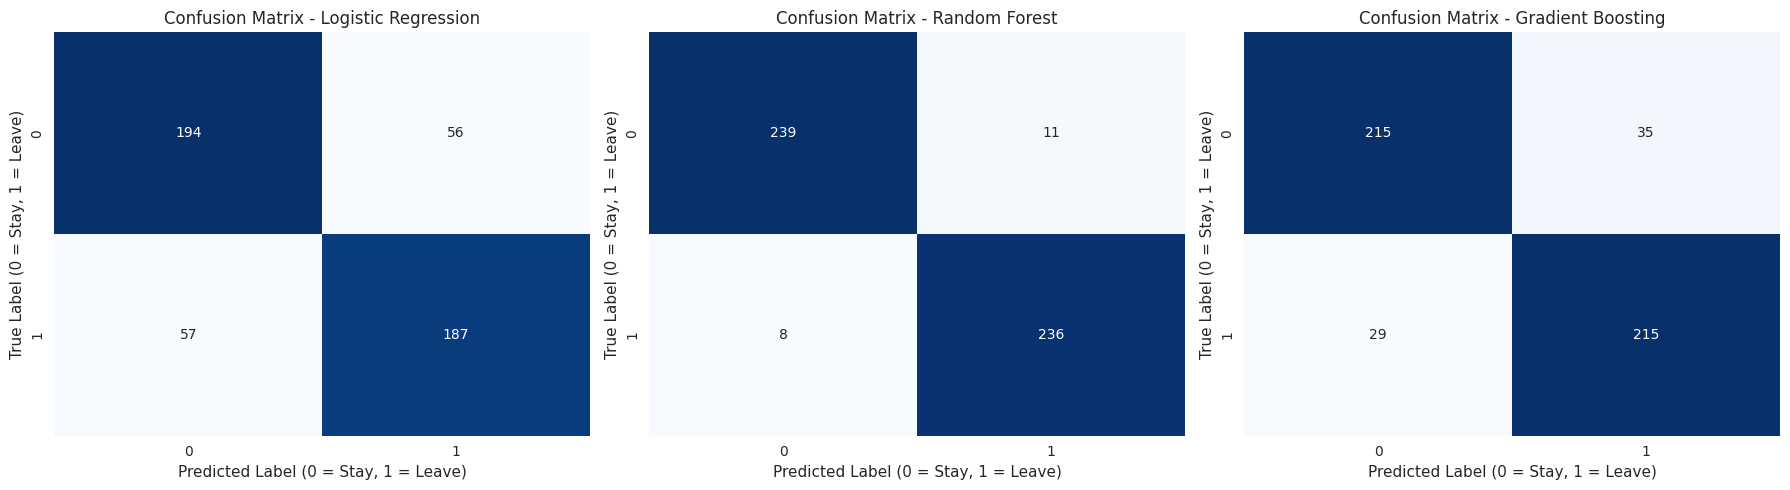

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = [
    (log_reg, 'Logistic Regression'),
    (rf_model, 'Random Forest'),
    (gb_model, 'Gradient Boosting')
]

for ax, (model, name) in zip(axes, models):
    # Predicting using each model
    y_pred = model.predict(testing_features)

    # Generating the confusion matrix
    cm = confusion_matrix(testing_target, y_pred)

    # Plotting it on the specific subplot (ax)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(f'Confusion Matrix - {name}')
    ax.set_xlabel('Predicted Label (0 = Stay, 1 = Leave)')
    ax.set_ylabel('True Label (0 = Stay, 1 = Leave)')

plt.tight_layout()
plt.show()

**Confusion Matrix for the Best Model (Random Forest)**
---

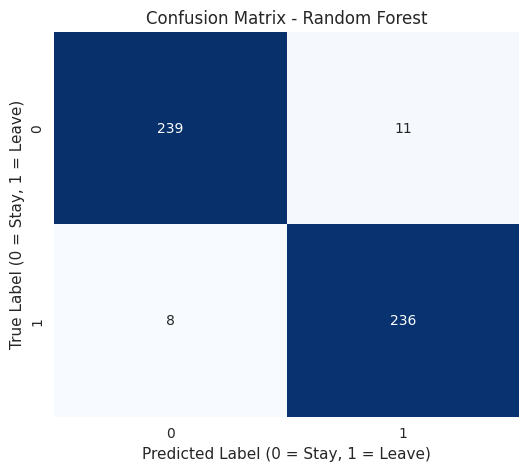

In [75]:
y_pred_best = rf_model.predict(testing_features)
cm = confusion_matrix(testing_target, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted Label (0 = Stay, 1 = Leave)')
plt.ylabel('True Label (0 = Stay, 1 = Leave)')
plt.show()

**ROC Curve Comparison**
---

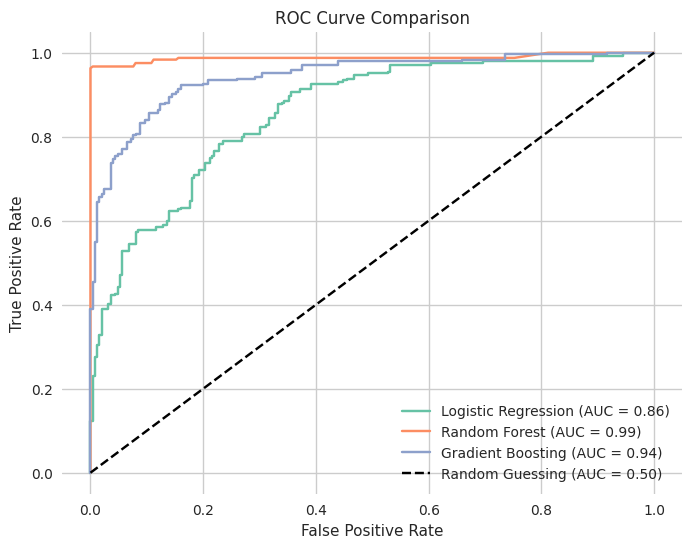

In [ ]:
plt.figure(figsize=(8, 6))

for model, name in zip([log_reg, rf_model, gb_model], ['Logistic Regression', 'Random Forest', 'Gradient Boosting']):
    y_prob = model.predict_proba(testing_features)[:, 1]
    fpr, tpr, _ = roc_curve(testing_target, y_prob)
    auc_score = roc_auc_score(testing_target, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing (AUC = 0.50)')
plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

Observation:
---
This chart visually proves why Random Forest is our absolute winner.

Random Forest (0.99): The orange line hugging the very top-left corner means this model is nearly perfect. It rarely gets confused—when it flags an employee as a flight risk, it is almost certainly right.

Gradient Boosting (0.94): The blue line is right behind it. It is a very smart model and does a fantastic job, it just makes a few more tiny mistakes than Random Forest.

Logistic Regression (0.86): The green line is at the bottom, but an 86% score is still a solid, passing grade in the real world! It just shows that a simple, straight-line formula isn't quite powerful enough to capture all the complex, hidden reasons why humans decide to quit their jobs.

**Feature Importance**
---

In [ ]:
# Identifying the most important features driving attrition from Random Forest
feature_importance = pd.DataFrame({
    "Feature": training_features.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)
display(feature_importance.head(10))

,Feature,Importance
9,MonthlyIncome,0.079176
43,OverTime_Yes,0.062126
0,Age,0.054047
16,TotalWorkingYears,0.050133
1,DailyRate,0.048496
19,YearsAtCompany,0.046173
5,HourlyRate,0.044502
10,MonthlyRate,0.042757
22,YearsWithCurrManager,0.039635
15,StockOptionLevel,0.039283


**Feature Importance Plot**
---

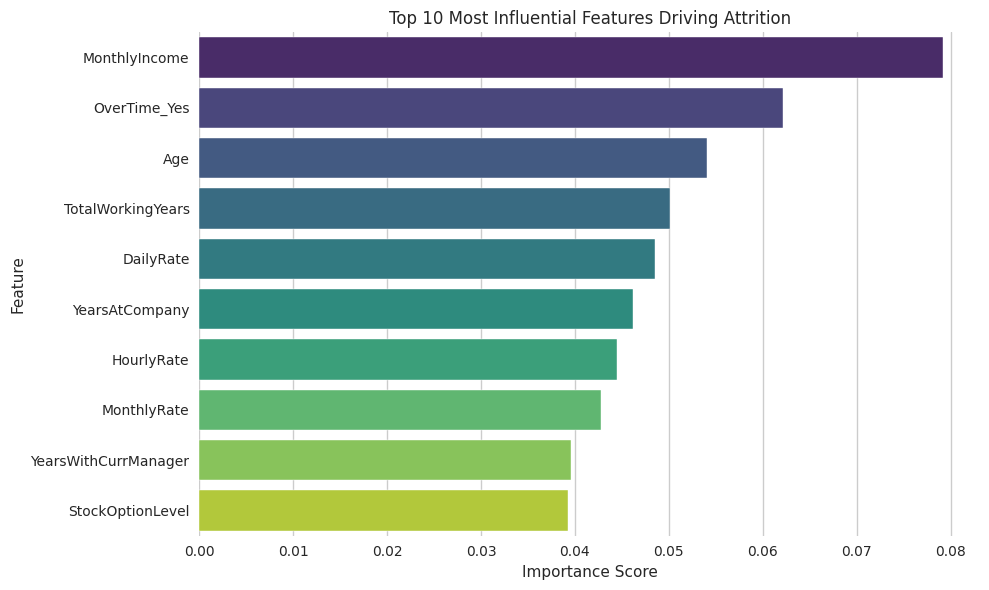

In [ ]:
# Plotting the top important features
plt.figure(figsize=(10,6))
sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature",
    palette="viridis"
)
plt.title("Top 10 Most Influential Features Driving Attrition")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

**9. Observations**
---

Based on exploring the data and evaluating our models, here are the main things I noticed about why employees decide to leave:

**1. Money is the Biggest reason:**

Looking at the feature importance chart, a person's Monthly Income is the absolute strongest predictor of whether they will stay or quit. Simply put, employees who aren't paid competitively are the most likely to walk out the door.

**2. The Burnout Factor (Overtime):**

Right behind salary is Overtime. Employees who are forced to work extra hours on a regular basis are at a massive risk of quitting. High pay might keep them around for a bit, but burnout is a huge breaking point.

**3. Age and Experience Matter:**

A person's Age and their Total Working Years are also top factors. Younger, less experienced employees tend to job-hop much more often than older, established professionals who have already spent years in the workforce.

**4. The "Danger Zone" for Newer Hires:**

The time an employee has spent at the company (Years at Company) is another strong trigger. As we saw in the charts earlier, if someone is going to leave, they usually do it during their first 2 to 5 years.

**5. Managers Have a Big Impact:**

The amount of time an employee has spent with their current manager (Years With Current Manager) made the top 10 list. This proves the old saying: "People don't quit jobs, they quit managers." A good or bad relationship with a boss heavily influences their decision to stay.




Once the data was balanced, the Random Forest model proved to be incredibly powerful. Not only did it give us highly accurate predictions, but it also let us peek under the hood (using the Feature Importance chart) to see exactly why it was making those predictions—like highlighting the massive impact of Salary and Overtime.

Overall, this project showed me how helpful machine learning can be in the real corporate world. By using predictive models, HR teams can stop guessing and actually use data to step in and save their best employees before they even hand in their resignation letters.










**Final HR Insights and Business Recommendations**
---

1. From this project, I learned exactly what makes an employee decide to leave a company.

2. If an employee is not being paid enough (Monthly Income) and is simultaneously being overworked (Overtime), they are almost guaranteed to start looking for a new job.


3. Based on our data, the top three factors driving employees to quit are:
* their monthly paycheck,
* the amount of overtime they work, and
* their age.

4. If HR wants to stop this attrition, they need to focus immediately on the **Sales Department**, particularly the **Sales Representatives** who are leaving at an alarming rate.

5. While a low salary is the strongest trigger for someone leaving, it definitely isn't the only reason; being forced to work constant overtime creates intense burnout that easily overrides a decent paycheck


6. If I were advising an HR Director based on this data, my main suggestions would be:

**a) Review Salaries for At-Risk Employees:**

Since Monthly Income is the biggest factor, HR needs to regularly check that salaries are competitive with the market—especially for younger employees who are in their first 2 to 5 years at the company.

**b) Control Overtime and Burnout:**

HR should actively track employees who log high overtime weeks consecutively and prompt managers to step in to balance the workload before the employee burns out and quits.

7. Finally, HR must remember that while this machine learning model is a great early-warning radar, its biggest limitation is that it cannot predict unpredictable real-life events, like a spouse relocating for work or a sudden family health crisis.


















**Conclusion**
---
This project was a great way to experience a complete classification machine learning workflow from start to finish. I started by cleaning and visualizing the dataset to understand HR trends, and then I prepared the data using one-hot encoding and scaling so the algorithms could read it.

By comparing Logistic Regression, Random Forest, and Gradient Boosting, I learned an important lesson about class imbalance and model selection. Because only 16% of employees actually left, it was critical to use the RandomOverSampler technique. Once the data was balanced, the Random Forest Regressor/Classifier emerged as the most powerful tool for predicting attrition and extracting Feature Importances.

Overall, this project showed me how helpful machine learning can be in the corporate world. By using predictive models, HR teams can get a fast, data-backed early warning system to retain top talent rather than just reacting after an employee has already resigned.